In [5]:
# Import libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle
import os
import statsmodels.api as sm

plt.style.use('seaborn-v0_8')


In [6]:
# Set the working directory
notebook_dir = os.getcwd() 
os.chdir(notebook_dir)

In [7]:
# Import dataset
data_path = os.path.join("Data", "df.xlsx")
df = pd.read_excel(data_path)

columns_to_round1 = ["GDP_Ger", "GDP_Sk", "GDP_Pol", "GDP_Fr", "GDP_Au", "GDP_It", "P_Cz", "P_Ger", "P_Sk", "P_Pol", "P_Fr", "P_Au", "P_It"]
df[columns_to_round1] = df[columns_to_round1].round(2)

columns_to_round2 = ["XR", "ULC", "Import"]
df[columns_to_round2] = df[columns_to_round2].round(3)

print(df.head())

        Date  Export   GDP_Ger    GDP_Sk   GDP_Pol    GDP_Fr   GDP_Au  \
0 2000-01-01  265447  595801.6  10570.20  60209.94  431559.5  62060.1   
1 2000-04-01  273804  600554.6  10620.96  60402.35  436384.2  62795.4   
2 2000-07-01  284184  600993.3  10623.35  62404.98  439740.2  63546.9   
3 2000-10-01  302375  598434.0  10521.37  64470.39  442413.8  64034.3   
4 2001-01-01  307443  611139.0  10711.84  66631.59  444726.2  63926.6   

     GDP_It      XR   P_Cz  P_Ger   P_Sk  P_Pol   P_Fr   P_Au   P_It     ULC  \
0  388892.7  35.771  89.52  91.91  73.38  84.82  89.90  90.60  87.90  71.824   
1  391455.2  36.289  89.82  91.93  74.90  86.30  90.07  90.80  88.17  72.016   
2  394994.8  35.459  91.04  92.47  75.90  88.55  90.70  91.26  88.90  72.935   
3  398822.1  34.911  91.97  93.13  76.85  89.85  91.21  91.96  89.48  74.602   
4  401960.3  34.798  93.17  93.38  78.66  90.53  91.20  92.42  89.77  74.895   

    Import  
0  103.400  
1  107.233  
2  108.667  
3  110.433  
4  107.533  


In [8]:
# Create new variable for foreing demand

weights = {
    "GDP_Ger": 0.518,
    "GDP_Sk": 0.128,
    "GDP_Pol": 0.111,
    "GDP_Fr": 0.086,
    "GDP_Au": 0.076,
    "GDP_It": 0.081
}

df["y"] = sum(df[col] * weight for col, weight in weights.items())

df["y"] = df["y"].round(2)

In [9]:
# Create new variables for price level
weights = {
    "P_Ger": 0.518,
    "P_Sk": 0.128,
    "P_Pol": 0.111,
    "P_Fr": 0.086,
    "P_Au": 0.076,
    "P_It": 0.081
}

df["P_for"] = sum(df[col] * weight for col, weight in weights.items())

df["P_for"] = df["P_for"].round(2)

In [10]:
# Create log variables
df["l_x"] = np.log(df["Export"])
df["l_y"] = np.log(df["y"])
df["l_e"] = np.log(df["XR"])
df["l_p_for"] = np.log(df["P_for"])
df["l_p_cz"] = np.log(df["P_Cz"])
df["l_ULC"] = np.log(df["ULC"])
df["l_m"] = np.log(df["Import"])

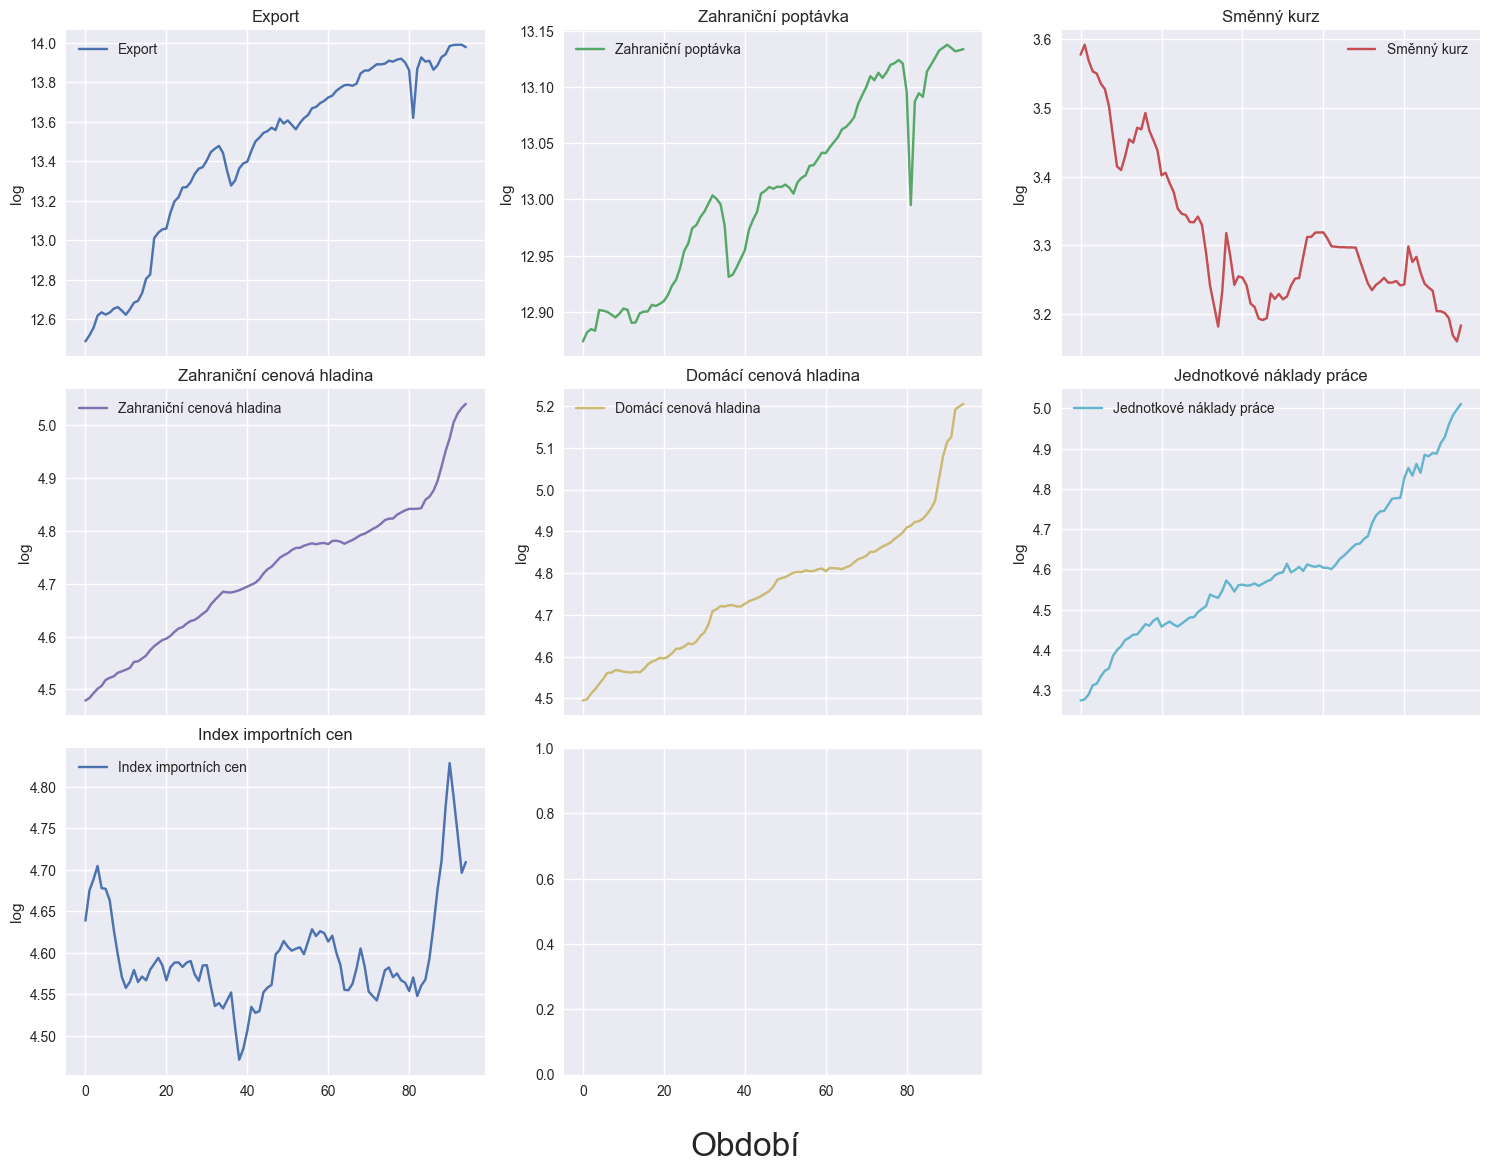

In [ ]:
# Vizualization on variables
variables = ["l_x", "l_y", "l_e", "l_p_for", "l_p_cz", "l_ULC", "l_m"]
title_map = {
    "l_x": "Export",
    "l_y": "Zahraniční poptávka",
    "l_e": "Směnný kurz",
    "l_p_for": "Zahraniční cenová hladina",
    "l_p_cz": "Domácí cenová hladina",
    "l_ULC": "Jednotkové náklady práce",
    "l_m": "Index importních cen"
}

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig, axes = plt.subplots(nrows = 3, ncols = 3, figsize = (15, 12), sharex = True)

axes = axes.flatten()

for i, var in enumerate(variables):
    axes[i].plot(df.index, df[var], label = title_map[var], color = colors[i % len(colors)])
    axes[i].set_title(title_map[var], fontsize = 12)
    axes[i].set_ylabel("log")
    axes[i].grid(True)
    axes[i].legend()

fig.delaxes(axes[-1])
fig.delaxes(axes[-2])

fig.text(0.5, 0.04, "Období", ha = "center", va = "center", fontsize = 24)
plt.tight_layout()
plt.subplots_adjust(bottom = 0.1)

#save_path = os.path.join("Obrázky", "logaritmus_cara.png")
#plt.savefig(save_path, dpi = 300, bbox_inches = "tight")

plt.show()

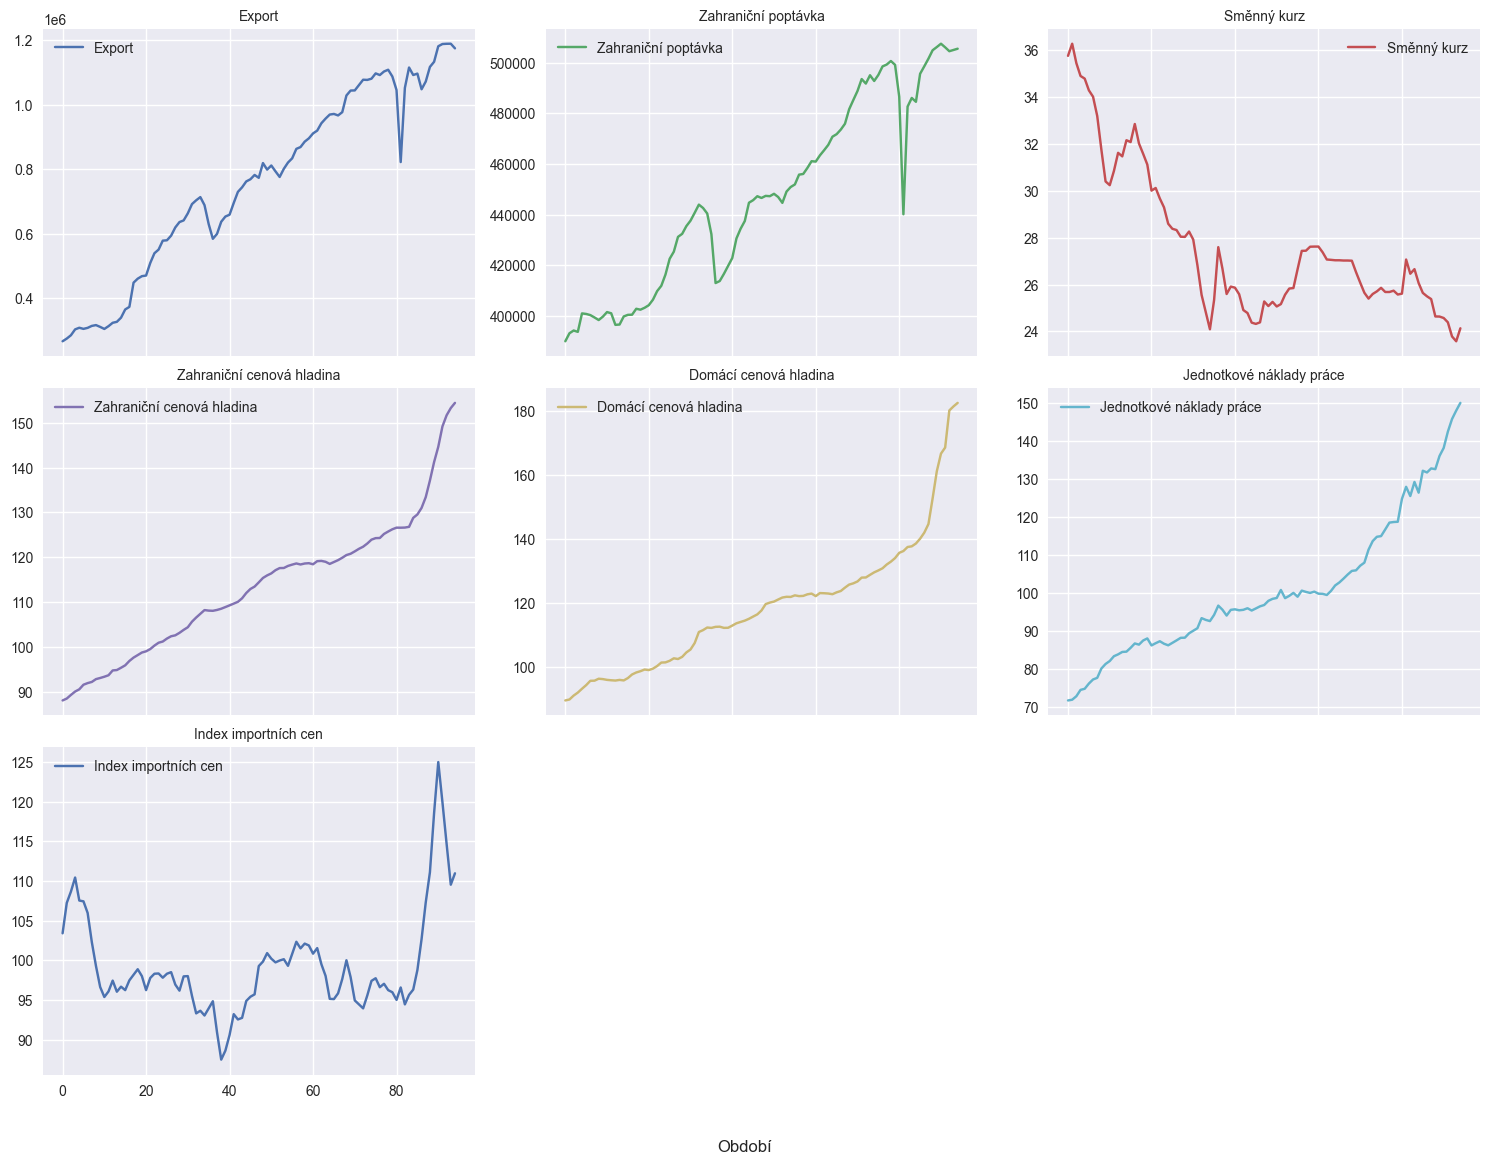

In [23]:
# Vizualization on variables
variables = ["Export", "y", "XR", "P_for", "P_Cz", "ULC", "Import"]
title_map = {
    "Export": "Export",
    "y": "Zahraniční poptávka",
    "XR": "Směnný kurz",
    "P_for": "Zahraniční cenová hladina",
    "P_Cz": "Domácí cenová hladina",
    "ULC": "Jednotkové náklady práce",
    "Import": "Index importních cen"
}

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig, axes = plt.subplots(nrows = 3, ncols = 3, figsize = (15, 12), sharex = True)

axes = axes.flatten()

for i, var in enumerate(variables):
    axes[i].plot(df.index, df[var], label = title_map[var], color = colors[i % len(colors)])
    axes[i].set_title(title_map[var], fontsize = 10)
    axes[i].grid(True)
    axes[i].legend()

fig.delaxes(axes[-1])
fig.delaxes(axes[-2])

fig.text(0.5, 0.04, "Období", ha = "center", va = "center", fontsize = 12)
plt.tight_layout()
plt.subplots_adjust(bottom = 0.1)

#save_path = os.path.join("Obrázky", "cara.png")
#plt.savefig(save_path, dpi = 300, bbox_inches = "tight")

plt.show()

In [36]:
# Import nezbytných knihoven
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import os
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import jarque_bera

# Seznam proměnných k dekompozici
variables = ["l_x", "l_y", "l_e", "l_p_for", "l_p_cz", "l_ULC", "l_m"]

# Slovník pro české názvy proměnných
title_map = {
    "l_x": "Export",
    "l_y": "Zahraniční poptávka",
    "l_e": "Směnný kurz",
    "l_p_for": "Zahraniční cenová hladina",
    "l_p_cz": "Domácí cenová hladina",
    "l_ULC": "Jednotkové náklady práce",
    "l_m": "Index importních cen"
}

# Smyčka přes všechny proměnné
for var in variables:
    # Kontrola, zda sloupec existuje
    if var not in df.columns:
        raise ValueError(f"Sloupec '{var}' nenalezen v DataFrame. Ujistěte se, že existuje.")
    
    # Kontrola chybějících hodnot
    if df[var].isna().any():
        raise ValueError(f"Sloupec '{var}' obsahuje chybějící hodnoty. Před pokračováním je prosím zpracujte.")
    
    # Christiano-Fitzgerald filtr (6–32 čtvrtletí pro hospodářské cykly)
    cycle = sm.tsa.filters.cf_filter.cffilter(df[var], low=6, high=32)[0]
    trend = df[var] - cycle
    
    # Uložení trendu a gapu
    df[f"{var}_trnd"] = trend
    df[f"{var}_gap"] = cycle
    
    # Statistické testy pro gap
    gap = df[f"{var}_gap"]
    print(f"\nOvěření gapu pro {var} ({title_map[var]}):")
    print(f"Průměr gapu: {gap.mean():.6f}")
    print(f"Směrodatná odchylka gapu: {gap.std():.6f}")
    
    # ADF test na stacionaritu
    adf_result = adfuller(gap)
    print(f"ADF test stacionarity (p-hodnota): {adf_result[1]:.6f}")
    print(f"  (p < 0.05 znamená, že gap je stacionární)")
    
    # Ljung-Box test na autokorelaci (prvních 5 lagů)
    lb_result = acorr_ljungbox(gap, lags=[5], return_df=True)
    print(f"Ljung-Box test (lag 5, p-hodnota): {lb_result['lb_pvalue'].iloc[0]:.6f}")
    print(f"  (p > 0.05 znamená absenci autokorelace)")
    
    # Jarque-Bera test na normalitu
    jb_stat, jb_pvalue = jarque_bera(gap)
    print(f"Jarque-Bera test normality (p-hodnota): {jb_pvalue:.6f}")
    print(f"  (p > 0.05 znamená přibližnou normalitu)")

# Vizualizace gapových složek (3x3 mřížka)
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12), sharex=True)
axes = axes.flatten()
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for i, var in enumerate(variables):
    axes[i].plot(df.index, df[f"{var}_gap"], label=title_map[var], color=colors[i % len(colors)])
    axes[i].set_title(f"Gap: {title_map[var]}", fontsize=10)
    axes[i].set_ylabel('Logaritmická hodnota')
    axes[i].grid(True)
    axes[i].legend()

# Odstranění prázdných subplotů
fig.delaxes(axes[-1])
fig.delaxes(axes[-2])

# Nastavení společného popisku osy x
fig.text(0.5, 0.04, 'Období', ha='center', va='center', fontsize=12)
plt.tight_layout()
plt.subplots_adjust(bottom=0.1)

# Uložení grafu
#save_path_plot = os.path.join('Data', 'gap_decomposition_cf.png')
#plt.savefig(save_path_plot, dpi=300, bbox_inches='tight')
plt.show()



AttributeError: module 'statsmodels.tsa.filters.api' has no attribute 'cf_filter'

In [37]:
from statsmodels.tsa.filters import cffilter

ImportError: cannot import name 'cffilter' from 'statsmodels.tsa.filters' (/opt/anaconda3/envs/data_analysis/lib/python3.12/site-packages/statsmodels/tsa/filters/__init__.py)